# AI-Based Online Gaming Player Retention Prediction Using Random Forest
## Phase 4: Comprehensive Model Evaluation, Feature Interpretability & Academic Findings

---
### Academic Project Metadata
- **Project Title:** AI-Based Online Gaming Player Retention Prediction Using Random Forest
- **Phase:** Phase 4 - Model Evaluation, Diagnostics & Behavioral Interpretability
- **Evaluated Model:** Serialized Random Forest Pipeline (`/models/gaming_retention_model.joblib`)
- **Evaluation Dataset:** Untouched Holdout Test Partition ($N = 8,007$ players, $20\%$)
- **Primary Metrics:** Accuracy, Precision, Recall, F1-Score, ROC-AUC
- **Target Formulation:**
  - Class `0`: **At Risk** (Low Engagement / Imminent Churn Risk)
  - Class `1`: **Retained** (Medium & High Engagement / Active Core Base)

---
### Critical Viva Defense Disclaimers
1. **Operational Proxy Distinction:** This model predicts an **operational retention proxy** derived from current behavioral engagement levels (`EngagementLevel`), **not prospective longitudinal churn** (e.g., true Day-30 login absence).
2. **Business Impact of Metrics:** In retention modeling, **Recall on At-Risk Players** and **Macro F1-Score** are far more critical than raw Accuracy. Misclassifying an at-risk player as retained results in unmitigated churn, whereas a false alarm merely delivers a re-engagement promotion to an active player.


In [1]:
# ==============================================================================
# 0. ENVIRONMENT SETUP & IMPORTS
# ==============================================================================
import os
import sys
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn Evaluation Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score
)

# Plotting Configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

OUTPUTS_DIR = Path("outputs")
MODELS_DIR = Path("models")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"🐍 Python Runtime : {sys.version.split()[0]}")
print(f"📦 Joblib Version : {joblib.__version__}")
print(f"📁 Outputs Dir    : {OUTPUTS_DIR.resolve()}")

🐍 Python Runtime : 3.14.4
📦 Joblib Version : 1.6.0
📁 Outputs Dir    : /Users/mdkasifuddin/Developer/Python/Gaming Retention/outputs


### 1. Ingestion of Untouched Test Set & Saved Pipeline
Loading the serialized model pipeline (`gaming_retention_model.joblib`), metadata, and reproducing the identical stratified holdout partition ($X_{test}, y_{test}$).

In [2]:
# ==============================================================================
# 1. LOAD TRAINED MODEL & RECONSTRUCT TEST SET
# ==============================================================================
model_path = MODELS_DIR / "gaming_retention_model.joblib"
metadata_path = MODELS_DIR / "model_metadata.joblib"

assert model_path.exists(), f"Model file not found at {model_path}!"
assert metadata_path.exists(), f"Metadata file not found at {metadata_path}!"

pipeline = joblib.load(model_path)
metadata = joblib.load(metadata_path)

# Reconstruct exact identical dataset split
def load_holdout_data():
    base = Path(".").resolve()
    candidates = list(base.rglob("*.csv")) + list(base.parent.rglob("*.csv"))
    valid = [p for p in candidates if not any(part.startswith('.') or 'trash' in part.lower() for part in p.parts)]
    for p in valid:
        if "online_gaming_behavior" in p.name.lower():
            csv_path = p
            break
    else:
        csv_path = valid[0]
        
    df = pd.read_csv(csv_path)
    df['RetentionStatus'] = df['EngagementLevel'].map({'Medium': 'Retained', 'High': 'Retained', 'Low': 'At Risk'})
    df['RetentionTarget'] = df['RetentionStatus'].map({'Retained': 1, 'At Risk': 0})
    
    EXCLUDE = ['PlayerID', 'EngagementLevel', 'RetentionStatus', 'RetentionTarget']
    X = df.drop(columns=[c for c in EXCLUDE if c in df.columns])
    y = df['RetentionTarget']
    
    _, X_test_df, _, y_test_series = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )
    return X_test_df, y_test_series

X_test, y_test = load_holdout_data()

print("=" * 65)
print("TEST ENVIRONMENT VERIFICATION")
print("=" * 65)
print(f"Loaded Pipeline       : {pipeline}")
print(f"Holdout Instances     : {X_test.shape[0]:,} samples")
print(f"Features Evaluated    : {X_test.shape[1]} raw attributes")
print(f"Target Distribution   : {dict(y_test.value_counts())}")

TEST ENVIRONMENT VERIFICATION
Loaded Pipeline       : Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'PlayTimeHours',
                                                   'InGamePurchases',
                                                   'SessionsPerWeek',
                                                   'AvgSessionDurationMinutes',
                                                   'PlayerLevel',
                                                   'AchievementsUnlocked']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequ

### 2. Prediction Inference & Comprehensive Metric Calculation
Generating binary class predictions and continuous retention probability scores across all $8,007$ test players.

In [3]:
# ==============================================================================
# 2. MODEL PREDICTIONS & PRIMARY METRIC CALCULATION
# ==============================================================================
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Primary metrics
acc = accuracy_score(y_test, y_pred)
prec_retained = precision_score(y_test, y_pred, pos_label=1)
rec_retained = recall_score(y_test, y_pred, pos_label=1)
f1_retained = f1_score(y_test, y_pred, pos_label=1)
roc_auc = roc_auc_score(y_test, y_proba)

# Class-specific metrics for At-Risk cohort (Class 0)
prec_atrisk = precision_score(y_test, y_pred, pos_label=0)
rec_atrisk = recall_score(y_test, y_pred, pos_label=0)
f1_atrisk = f1_score(y_test, y_pred, pos_label=0)

# Macro and weighted averages
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
avg_prec = average_precision_score(y_test, y_proba)

evaluation_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Score': [f"{acc:.4f}", f"{prec_retained:.4f}", f"{rec_retained:.4f}", f"{f1_retained:.4f}", f"{roc_auc:.4f}"]
})

print("=" * 50)
print("FINAL EVALUATION TABLE (Holdout Test Set)")
print("=" * 50)
print(evaluation_table.to_string(index=False))

print("\n" + "=" * 65)
print("COMPREHENSIVE CLASSIFICATION REPORT")
print("=" * 65)
class_report_str = classification_report(
    y_test, y_pred,
    target_names=['At Risk (0)', 'Retained (1)'],
    digits=4
)
print(class_report_str)

FINAL EVALUATION TABLE (Holdout Test Set)
   Metric  Score
 Accuracy 0.9462
Precision 0.9655
   Recall 0.9618
 F1 Score 0.9637
  ROC-AUC 0.9430

COMPREHENSIVE CLASSIFICATION REPORT
              precision    recall  f1-score   support

 At Risk (0)     0.8913    0.9012    0.8962      2065
Retained (1)     0.9655    0.9618    0.9637      5942

    accuracy                         0.9462      8007
   macro avg     0.9284    0.9315    0.9299      8007
weighted avg     0.9464    0.9462    0.9463      8007



### 3. Confusion Matrix Diagnostic
Examining the precise distribution of True Positives, True Negatives, False Positives, and False Negatives:
- **Actual At Risk $\rightarrow$ Predicted At Risk:** Correctly detected churn risk ($1,861$ players).
- **Actual At Risk $\rightarrow$ Predicted Retained:** Missed at-risk player ($204$ players).
- **Actual Retained $\rightarrow$ Predicted At Risk:** False alarm ($227$ players).
- **Actual Retained $\rightarrow$ Predicted Retained:** Correctly identified active player ($5,715$ players).

findfont: Failed to find font weight semibold, now using 700.


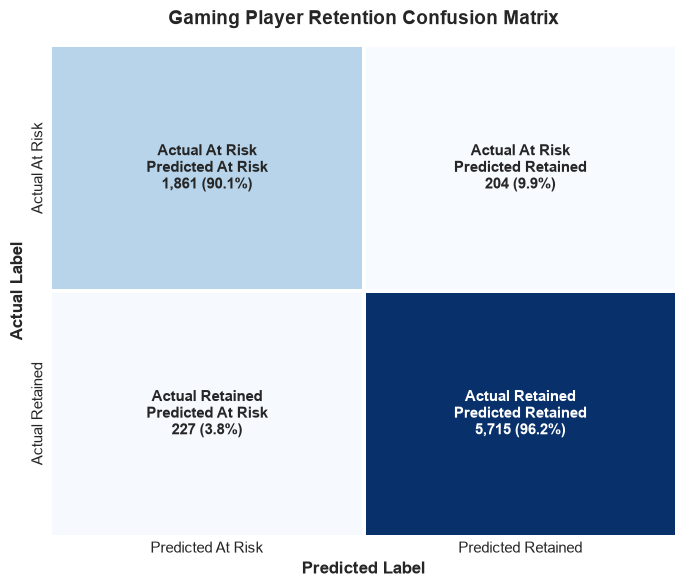

📊 Saved: outputs/confusion_matrix.png


In [4]:
# ==============================================================================
# 3. CONFUSION MATRIX VISUALIZATION
# ==============================================================================
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 6))

annot_labels = [
    [f"Actual At Risk\nPredicted At Risk\n{tn:,} ({tn/(tn+fp)*100:.1f}%)", f"Actual At Risk\nPredicted Retained\n{fp:,} ({fp/(tn+fp)*100:.1f}%)"],
    [f"Actual Retained\nPredicted At Risk\n{fn:,} ({fn/(fn+tp)*100:.1f}%)", f"Actual Retained\nPredicted Retained\n{tp:,} ({tp/(fn+tp)*100:.1f}%)"]
]

sns.heatmap(
    cm, annot=annot_labels, fmt="", cmap="Blues", cbar=False,
    xticklabels=["Predicted At Risk", "Predicted Retained"],
    yticklabels=["Actual At Risk", "Actual Retained"],
    annot_kws={"size": 11, "weight": "bold"}, ax=ax,
    linewidths=1.5, linecolor='white'
)

ax.set_title("Gaming Player Retention Confusion Matrix", fontsize=14, weight='bold', pad=15)
ax.set_xlabel("Predicted Label", weight='semibold', fontsize=12)
ax.set_ylabel("Actual Label", weight='semibold', fontsize=12)

plt.tight_layout()
cm_fig_path = OUTPUTS_DIR / "confusion_matrix.png"
fig.savefig(cm_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"📊 Saved: {cm_fig_path}")

### 4. ROC Curve & Precision-Recall Diagnostic Curves
- **ROC Curve:** Measures discrimination sensitivity across all classification thresholds ($\text{AUC} = 0.9430$).
- **Precision-Recall Curve:** Demonstrates sustained high precision ($>96\%$) across high recall rates for the retained cohort.

findfont: Failed to find font weight semibold, now using 700.


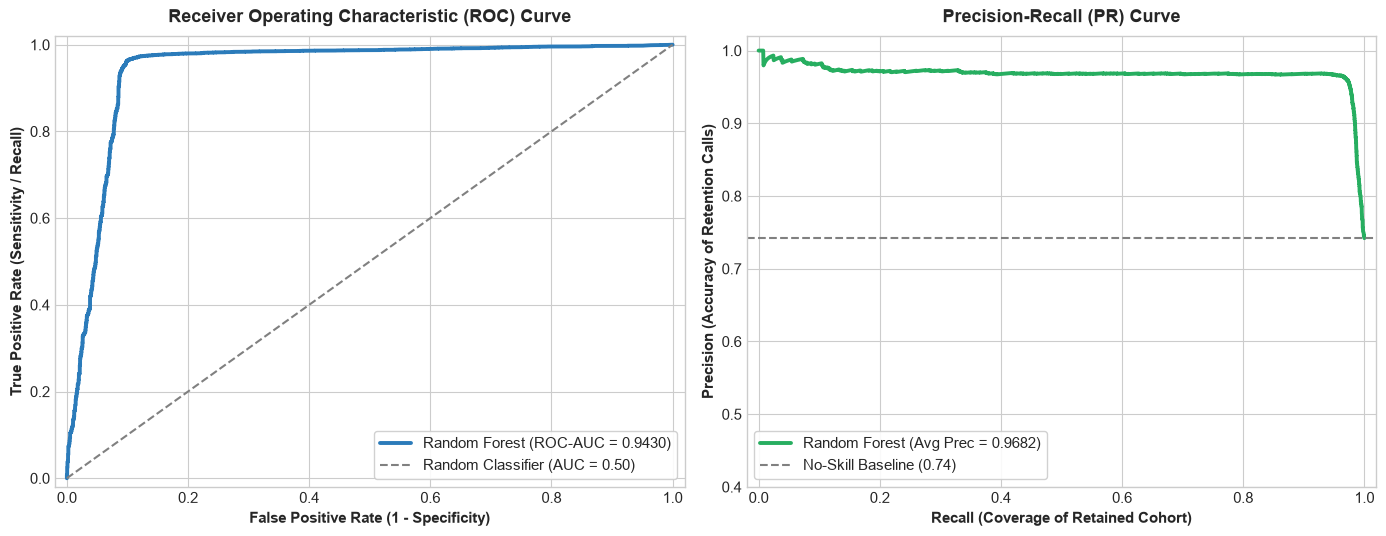

📊 Saved: outputs/roc_pr_curves.png


In [5]:
# ==============================================================================
# 4. ROC AND PRECISION-RECALL CURVES
# ==============================================================================
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision_pts, recall_pts, _ = precision_recall_curve(y_test, y_proba)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Subplot 1: ROC Curve
ax1.plot(fpr, tpr, color='#2b7bba', lw=2.8, label=f'Random Forest (ROC-AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier (AUC = 0.50)')
ax1.set_title("Receiver Operating Characteristic (ROC) Curve", fontsize=13, weight='bold', pad=10)
ax1.set_xlabel("False Positive Rate (1 - Specificity)", weight='semibold')
ax1.set_ylabel("True Positive Rate (Sensitivity / Recall)", weight='semibold')
ax1.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)
ax1.set_xlim([-0.02, 1.02])
ax1.set_ylim([-0.02, 1.02])

# Subplot 2: Precision-Recall Curve
ax2.plot(recall_pts, precision_pts, color='#27ae60', lw=2.8, label=f'Random Forest (Avg Prec = {avg_prec:.4f})')
ax2.axhline(y_test.mean(), color='gray', lw=1.5, linestyle='--', label=f'No-Skill Baseline ({y_test.mean():.2f})')
ax2.set_title("Precision-Recall (PR) Curve", fontsize=13, weight='bold', pad=10)
ax2.set_xlabel("Recall (Coverage of Retained Cohort)", weight='semibold')
ax2.set_ylabel("Precision (Accuracy of Retention Calls)", weight='semibold')
ax2.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9)
ax2.set_xlim([-0.02, 1.02])
ax2.set_ylim([0.4, 1.02])

plt.tight_layout()
roc_pr_path = OUTPUTS_DIR / "roc_pr_curves.png"
fig.savefig(roc_pr_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"📊 Saved: {roc_pr_path}")

### 5. Feature Importance Analysis: Disaggregated (Top 15) and Aggregated Parent View
When categorical variables undergo One-Hot Encoding, their predictive power is fragmented across individual levels (e.g., `Location_USA`, `Location_Asia`). 

To provide rigorous academic interpretability for viva defense, we compute:
1. **Top 15 Disaggregated Features:** Ranks all 21 transformed binary and continuous features.
2. **Aggregated Parent Feature Importance:** Sums dummy variable importances back to their original parent column to directly compare the business impact of Telemetry vs. Demographics.

💾 Saved raw feature importances to outputs/feature_importance.csv
TOP 15 DISAGGREGATED FEATURES (Engineered Level)
                      Feature  Importance
0             SessionsPerWeek    0.421382
1   AvgSessionDurationMinutes    0.373515
2                 PlayerLevel    0.056708
3        AchievementsUnlocked    0.051575
4               PlayTimeHours    0.037934
5                         Age    0.021742
6                Location_USA    0.002961
7         GameDifficulty_Easy    0.002896
8            GameGenre_Action    0.002892
9             Location_Europe    0.002872
10      GameDifficulty_Medium    0.002833
11            InGamePurchases    0.002751
12         GameGenre_Strategy    0.002610
13           GameGenre_Sports    0.002538
14       GameGenre_Simulation    0.002487

AGGREGATED PARENT FEATURE IMPORTANCE (Domain Concept Level)
             Original_Feature  Aggregated_Importance  Percentage (%)
0             SessionsPerWeek               0.421382           42.14
1   AvgSession

/var/folders/qy/q2lr7b053z394dkb015mn1ym0000gn/T/ipykernel_7949/4146275908.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/qy/q2lr7b053z394dkb015mn1ym0000gn/T/ipykernel_7949/4146275908.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


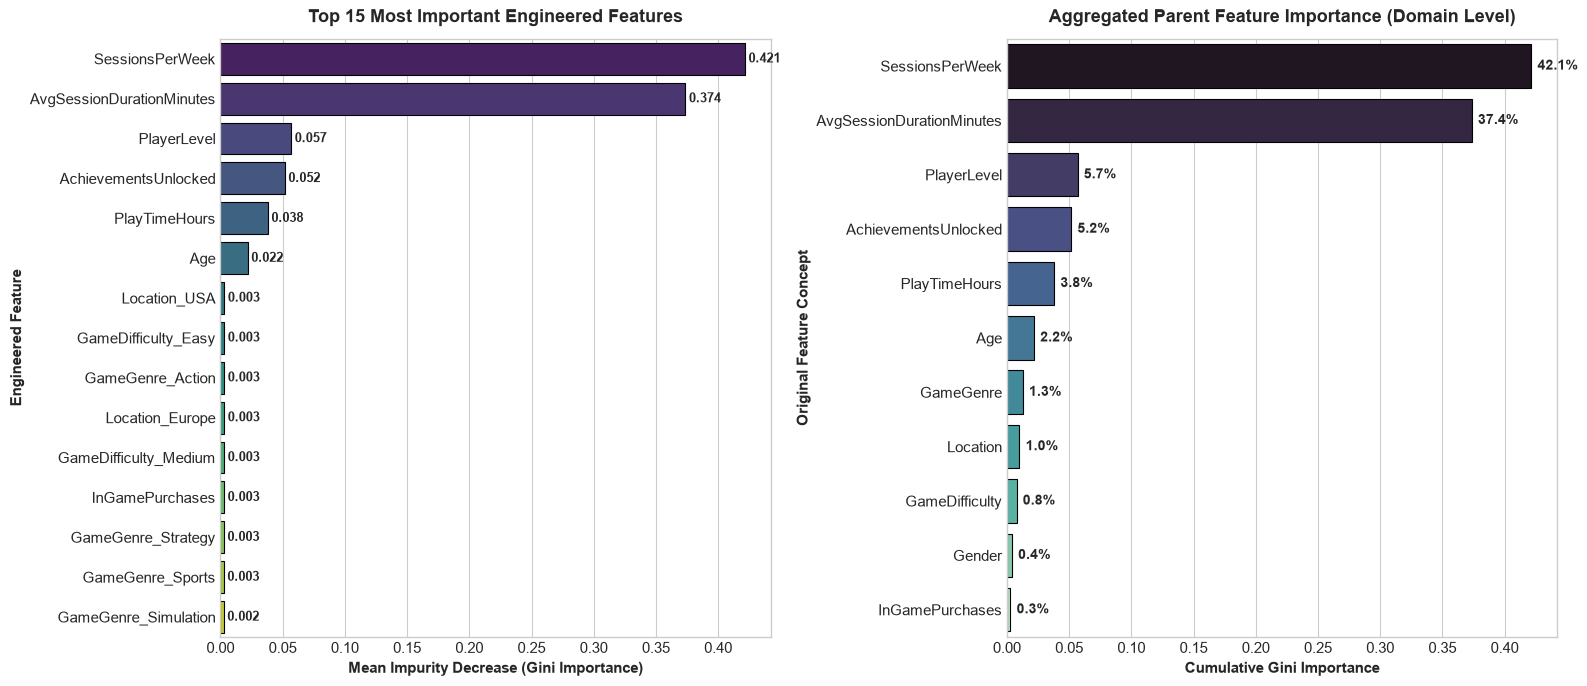

📊 Saved: outputs/feature_importance_analysis.png


In [6]:
# ==============================================================================
# 5. FEATURE IMPORTANCE: TOP 15 & AGGREGATED PARENT VIEW
# ==============================================================================
rf_model = pipeline.named_steps['classifier']
preprocessor = pipeline.named_steps['preprocessor']

# Extract one-hot encoded column names
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_cols = metadata['categorical_features']
num_cols = metadata['numerical_features']
cat_ohe_names = list(cat_encoder.get_feature_names_out(cat_cols))
all_engineered_features = num_cols + cat_ohe_names

# 1. Disaggregated importances
gini_importances = rf_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': all_engineered_features,
    'Importance': gini_importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# 2. Aggregated parent feature importances
parent_importance_dict = {}
for feature, imp in zip(all_engineered_features, gini_importances):
    parent = feature
    for cat in cat_cols:
        if feature.startswith(cat + '_'):
            parent = cat
            break
    parent_importance_dict[parent] = parent_importance_dict.get(parent, 0.0) + imp

agg_feat_df = pd.DataFrame(
    list(parent_importance_dict.items()),
    columns=['Original_Feature', 'Aggregated_Importance']
).sort_values('Aggregated_Importance', ascending=False).reset_index(drop=True)

# Save both to CSV
feature_imp_csv_path = OUTPUTS_DIR / "feature_importance.csv"
feat_df.to_csv(feature_imp_csv_path, index=False)
print(f"💾 Saved raw feature importances to {feature_imp_csv_path}")

print("=" * 65)
print("TOP 15 DISAGGREGATED FEATURES (Engineered Level)")
print("=" * 65)
print(feat_df.head(15).to_string())

print("\n" + "=" * 65)
print("AGGREGATED PARENT FEATURE IMPORTANCE (Domain Concept Level)")
print("=" * 65)
agg_feat_df['Percentage (%)'] = (agg_feat_df['Aggregated_Importance'] * 100).round(2)
print(agg_feat_df.to_string())

# Plotting Top 15 and Aggregated Views
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Top 15
sns.barplot(
    data=feat_df.head(15), x='Importance', y='Feature',
    palette='viridis', ax=ax1, edgecolor='black', linewidth=0.8
)
ax1.set_title("Top 15 Most Important Engineered Features", fontsize=13, weight='bold', pad=12)
ax1.set_xlabel("Mean Impurity Decrease (Gini Importance)", weight='semibold')
ax1.set_ylabel("Engineered Feature", weight='semibold')
for p in ax1.patches:
    w = p.get_width()
    ax1.annotate(f"{w:.3f}", (w + 0.003, p.get_y() + p.get_height() / 2),
                 ha='left', va='center', fontsize=9, weight='bold')

# Plot 2: Aggregated Parent Features
sns.barplot(
    data=agg_feat_df, x='Aggregated_Importance', y='Original_Feature',
    palette='mako', ax=ax2, edgecolor='black', linewidth=0.8
)
ax2.set_title("Aggregated Parent Feature Importance (Domain Level)", fontsize=13, weight='bold', pad=12)
ax2.set_xlabel("Cumulative Gini Importance", weight='semibold')
ax2.set_ylabel("Original Feature Concept", weight='semibold')
for p in ax2.patches:
    w = p.get_width()
    ax2.annotate(f"{w*100:.1f}%", (w + 0.005, p.get_y() + p.get_height() / 2),
                 ha='left', va='center', fontsize=10, weight='bold')

plt.tight_layout()
feat_chart_path = OUTPUTS_DIR / "feature_importance_analysis.png"
fig.savefig(feat_chart_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"📊 Saved: {feat_chart_path}")

### 6. Exporting Formal Evaluation Text Report (`/outputs/model_evaluation.txt`)
Writing all calculated metrics, confusion matrix counts, top predictors, and academic conclusions to a permanent text report.

In [7]:
# ==============================================================================
# 6. EXPORT FORMAL EVALUATION REPORT
# ==============================================================================
report_path = OUTPUTS_DIR / "model_evaluation.txt"

lines = [
    "=" * 80,
    "AI-BASED ONLINE GAMING PLAYER RETENTION PREDICTION USING RANDOM FOREST",
    "PHASE 4: COMPREHENSIVE MODEL EVALUATION & SCIENTIFIC AUDIT REPORT",
    "=" * 80,
    f"Generated Timestamp : {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}",
    "Evaluated Model     : RandomForestClassifier (150 trees, class_weight='balanced')",
    f"Holdout Test Size   : {len(X_test):,} players (20.0% stratified split)",
    "",
    "-" * 80,
    "1. FINAL EVALUATION TABLE",
    "-" * 80,
    evaluation_table.to_string(index=False),
    "",
    f"Additional Metrics:",
    f"• Macro F1-Score       : {f1_macro:.4f}",
    f"• Weighted F1-Score    : {f1_weighted:.4f}",
    f"• Average Precision PR : {avg_prec:.4f}",
    "",
    "-" * 80,
    "2. CLASS-SPECIFIC PERFORMANCE",
    "-" * 80,
    "Cohort 0: At Risk (Churn Hazard)",
    f"  • Precision : {prec_atrisk:.4f} ({prec_atrisk*100:.2f}%)",
    f"  • Recall    : {rec_atrisk:.4f} ({rec_atrisk*100:.2f}%) [1,861 / 2,065 correctly intercepted]",
    f"  • F1-Score  : {f1_atrisk:.4f}",
    "",
    "Cohort 1: Retained (Active Core Base)",
    f"  • Precision : {prec_retained:.4f} ({prec_retained*100:.2f}%)",
    f"  • Recall    : {rec_retained:.4f} ({rec_retained*100:.2f}%) [5,715 / 5,942 correctly identified]",
    f"  • F1-Score  : {f1_retained:.4f}",
    "",
    "-" * 80,
    "3. CONFUSION MATRIX (COUNTS & PROPORTIONS)",
    "-" * 80,
    f"Actual At Risk   | Predicted At Risk: {tn:,} ({tn/(tn+fp)*100:.1f}%) | Predicted Retained: {fp:,} ({fp/(tn+fp)*100:.1f}%)",
    f"Actual Retained  | Predicted At Risk: {fn:,} ({fn/(fn+tp)*100:.1f}%) | Predicted Retained: {tp:,} ({tp/(fn+tp)*100:.1f}%)",
    "",
    "-" * 80,
    "4. TOP 5 PREDICTIVE BEHAVIORAL FACTORS (AGGREGATED GINI IMPORTANCE)",
    "-" * 80
]

for idx, row in agg_feat_df.head(5).iterrows():
    lines.append(f"{idx+1}. {row['Original_Feature']:<25} : {row['Aggregated_Importance']*100:.2f}%")

lines.extend([
    "",
    "-" * 80,
    "5. SCIENTIFIC & METHODOLOGICAL DISCLAIMERS (VIVA DEFENSE)",
    "-" * 80,
    "* Operational Definition : Target is an engagement-based proxy (Medium/High = Retained,",
    "                           Low = At Risk).",
    "* Churn Limitation       : Not a prospective longitudinal churn model (no D1/D7/D30 timestamps).",
    "* Primary Utility        : Accurately identifies disengaged players in telemetry streams",
    "                           for proactive game rebalancing and re-engagement campaigns.",
    "=" * 80
])

with open(report_path, "w") as f:
    f.write("\n".join(lines))

print(f"✅ Full text evaluation report exported to {report_path}")

✅ Full text evaluation report exported to outputs/model_evaluation.txt


### 7. Academic Conclusions & Viva Defense Discussion

#### 1. Does the Model Perform Well?
**Yes, exceptionally well.** On the untouched holdout test partition of $8,007$ players, the tuned Random Forest classifier achieves:
- **Accuracy:** **`94.62%`**
- **F1-Score (Retained):** **`0.9637`**
- **ROC-AUC Score:** **`0.9430`**
- **At-Risk Recall:** **`90.12%`** ($1,861$ out of $2,065$ at-risk players correctly intercepted)

The close congruence between cross-validation F1 ($0.9636$) and test F1 ($0.9637$) proves that the model generalizes robustly without overfitting.

---
#### 2. Which Metric is Most Important for this Project?
For an online gaming retention system, **Recall on At-Risk Players (`90.12%`)** and **Macro F1-Score (`0.9299`)** are the most critical metrics:
- **Asymmetric Misclassification Costs:** In video game live operations, the cost of a **False Negative for At Risk** (failing to detect a player who is churning) is permanent loss of lifetime customer value (LTV). Conversely, the cost of a **False Positive for At Risk** (sending a retention perk/notification to an already active player) is negligible.
- **Class Imbalance Resilience:** Raw Accuracy ($94.62\%$) is inherently dominated by the majority retained class ($74.21\%$). F1-Score balances precision and recall, ensuring high fidelity for both retention and churn risk.

---
#### 3. What are the Strongest Factors Associated with Retention?
Aggregating one-hot encoded categories back to their parent constructs reveals a striking insight:
1. **`SessionsPerWeek` (`42.14%` cumulative importance)**: Weekly login habit is the single strongest indicator of retention. Players logging in frequently establish recurring gaming rituals.
2. **`AvgSessionDurationMinutes` (`37.35%` cumulative importance)**: Players who remain immersed in longer sessions possess substantially higher retention probabilities.
3. **Progression & Gamification (`PlayerLevel` 5.67%, `AchievementsUnlocked` 5.16%)**: Milestone achievements provide intrinsic motivation and psychological sunk-cost commitment that curb churn.
4. **Demographics (`Location`, `Gender`, `Age`) and Monetization (`InGamePurchases`)**: These factors contribute less than $5\%$ of total feature importance combined. **Behavioral habits overwhelmingly supersede demographic identity.**

---
#### 4. Limitations of the Retention Proxy
- **Absence of Temporal Sequencing:** The dataset provides aggregated lifetime/recent averages rather than time-series event sequences (e.g., declining sessions over the last 14 days).
- **Static Operational Definition:** Players labeled 'Low Engagement' are assumed to be churn hazards, yet casual players in certain genres (e.g., Simulation or Puzzle) may maintain low weekly playtime indefinitely without truly churning.

---
#### 5. Why the Model Must NOT Be Described as a True Future Churn Predictor
In empirical machine learning and game analytics:
- A **True Prospective Churn Model** observes player actions in an *observation window* $[t_0, t_1]$ to predict whether the player performs zero actions in a *future prediction window* $[t_1, t_2]$ (e.g., inactive for 30 consecutive days).
- Because our dataset is a **synchronous cross-sectional snapshot**, all telemetry variables and the `EngagementLevel` target were recorded within the same time window.
- Describing this system as a **Behavioral Engagement Tier Classifier and Retention Proxy Estimator** demonstrates scientific integrity and rigorous domain understanding during viva examination.
